In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import uniform_filter
import napari

SMOOTH_SIGMA = 5
AUC_BINS = 16


def smooth_paramap(data, seg, sigma=SMOOTH_SIGMA):
    filled = np.where((seg > 0) & np.isfinite(data), data, 0.0)
    smoothed = uniform_filter(filled, size=sigma)
    smoothed[seg == 0] = np.nan
    return smoothed


def to_label_layer(data, seg, n_bins=None):
    valid = data[seg > 0]
    valid = valid[~np.isnan(valid)]
    vmin = float(np.percentile(valid, 1))
    vmax = float(np.percentile(valid, 99))

    out = np.zeros_like(data, dtype=np.int32)
    mask = (seg > 0) & np.isfinite(data)

    if n_bins is not None:
        bins = np.linspace(vmin, vmax, n_bins + 1)
        out[mask] = np.digitize(data[mask], bins)
    else:
        out[mask] = np.round(data[mask]).astype(np.int32)

    out[~mask] = 0
    return out


def ordered_label_colors(label_array, cmap_name='plasma'):
    """Assign sequential colors to labels in sorted order — no cycling."""
    labels = np.sort(np.unique(label_array))
    labels = labels[labels != 0]
    n = len(labels)
    base = plt.get_cmap(cmap_name)
    color_dict = {0: [0, 0, 0, 0]}
    for i, lbl in enumerate(labels):
        color_dict[int(lbl)] = list(base(i / max(n - 1, 1)))
    return color_dict


pe  = np.load('/Users/samantha/Desktop/tul/china data/p34/new_v1/big_paramap/PE_full_TIC_numerical.npy')
t0  = np.load('/Users/samantha/Desktop/tul/china data/p34/new_v1/big_paramap/T0_full_TIC_numerical.npy')
tp  = np.load('/Users/samantha/Desktop/tul/china data/p34/new_v1/big_paramap/TP_full_TIC_numerical.npy')
auc = np.load('/Users/samantha/Desktop/tul/china data/p34/new_v1/big_paramap/AUC_full_TIC_numerical.npy')
seg = np.load('/Users/samantha/Desktop/tul/china data/p34/new_v1/big_paramap/segmentation.npy')
im  = np.load('/Users/samantha/Desktop/tul/china data/p34/new_v1/big_paramap/image.npy')

pe_s  = smooth_paramap(pe,  seg)
t0_s  = smooth_paramap(t0,  seg)
tp_s  = smooth_paramap(tp,  seg)
auc_s = smooth_paramap(auc, seg)

pe_labels  = to_label_layer(pe_s,  seg)
t0_labels  = to_label_layer(t0_s,  seg)
tp_labels  = to_label_layer(tp_s,  seg)
auc_labels = to_label_layer(auc_s, seg, AUC_BINS)

viewer = napari.Viewer()
viewer.add_image(im[..., 20], name='B-mode', colormap='gray')

pe_layer  = viewer.add_labels(pe_labels,  name='PE',  opacity=0.7, visible=True)
t0_layer  = viewer.add_labels(t0_labels,  name='T0',  opacity=0.7, visible=False)
tp_layer  = viewer.add_labels(tp_labels,  name='TP',  opacity=0.7, visible=False)
auc_layer = viewer.add_labels(auc_labels, name='AUC', opacity=0.7, visible=False)

pe_layer.color  = ordered_label_colors(pe_labels)
t0_layer.color  = ordered_label_colors(t0_labels)
tp_layer.color  = ordered_label_colors(tp_labels)
auc_layer.color = ordered_label_colors(auc_labels)

viewer.add_labels(seg.astype(np.int32), name='VOI', opacity=0.2)

# Add empty ROI layer — select it in the layer list and paint over the lesion, then close the viewer
roi_layer = viewer.add_labels(np.zeros(pe.shape, dtype=np.int32), name='Lesion ROI')

viewer.layers.selection.active = roi_layer
print("Active layer set to 'Lesion ROI' — ready to paint.")
print("  Label 1 = lesion (default)")
print("  Label 2 = necrosis (change in label selector before painting)")

napari.run()


# Parametric Map Visualization

Visualizes pre-computed CEUS parametric maps (PE, T0, TP, AUC) overlaid on B-mode ultrasound using Napari. Two viewer approaches are provided: a label-based discrete colormap and an image-based HSV colormap with a matplotlib legend. Both support interactively painting a lesion ROI (with optional necrosis exclusion) to extract mean parameter values per region. A static matplotlib slice preview is also included for quick inspection without opening Napari.

## Viewer 1: Label-based Colormap (Discrete Bins via `add_labels`)

Loads paramap `.npy` files, smooths them with a uniform filter, bins values into discrete integer labels, and displays them in Napari using `add_labels`. Paint label 1 for lesion, label 2 for necrosis on the `Lesion ROI` layer, then close the viewer and run the next cell.

# Parametric Map Visualization

Interactive viewer for CEUS parametric maps (PE, T0, TP, AUC) overlaid on B-mode ultrasound using Napari. Supports painting a lesion ROI to extract mean parameter values, with optional necrosis exclusion.

In [ ]:
# After closing the viewer: run this cell to get mean parameter values in your painted ROI.
# In the viewer, paint with label=1 for lesion, label=2 for necrosis (change in the label selector).
# Necrotic voxels are excluded from the means.

lesion_mask  = roi_layer.data == 1
necrosis_mask = roi_layer.data == 2
final_mask = lesion_mask & ~necrosis_mask

if final_mask.any():
    print(f"Lesion voxels      : {lesion_mask.sum()}")
    print(f"Necrosis voxels    : {necrosis_mask.sum()}")
    print(f"Voxels after excl. : {final_mask.sum()}")
    print()
    print(f"Mean PE  : {np.nanmean(pe[final_mask]):.4f}")
    print(f"Mean AUC : {np.nanmean(auc[final_mask]):.4f}")
    print(f"Mean TP  : {np.nanmean(tp[final_mask]):.4f}")
    print(f"Mean T0  : {np.nanmean(t0[final_mask]):.4f}")
else:
    print("No lesion painted — paint label=1 for lesion, label=2 for necrosis.")


### Extract Mean Parameters from Painted ROI (Viewer 1)

After closing the Napari viewer, computes mean PE, AUC, TP, and T0 for the painted lesion region, excluding any voxels marked as necrosis.

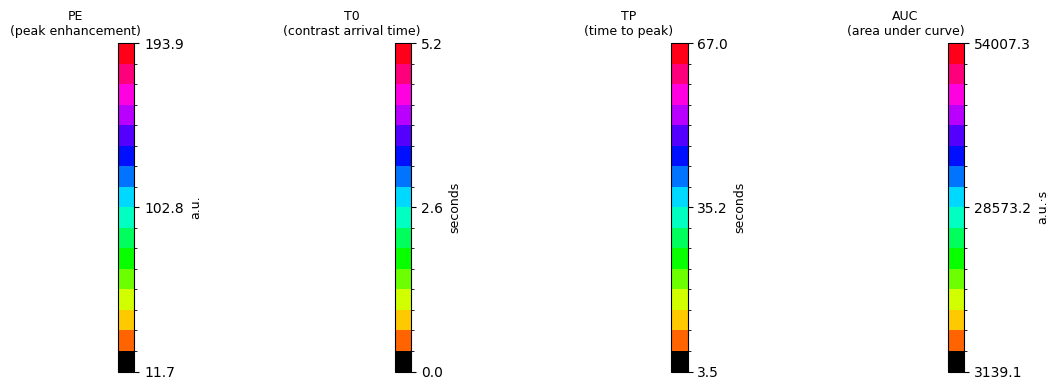

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import napari
from napari.utils.colormaps import Colormap

N_BINS = 16


def make_discrete_cmap(data, seg, name, n_bins=N_BINS):
    valid = data[seg > 0]
    valid = valid[~np.isnan(valid)]
    vmin = float(np.percentile(valid, 1))
    vmax = float(np.percentile(valid, 99))

    base = plt.get_cmap('hsv', n_bins)
    colors = np.array([base(i) for i in range(n_bins)])
    colors[0] = [0.0, 0.0, 0.0, 1.0]  # background -> black

    controls = np.linspace(0.0, 1.0, n_bins + 1)
    cmap = Colormap(name=name, colors=colors, controls=controls, interpolation='zero')
    bin_edges = np.linspace(vmin, vmax, n_bins + 1)
    return cmap, vmin, vmax, bin_edges


def show_legend(cmap_info: dict):
    n_maps = len(cmap_info)
    fig, axes = plt.subplots(1, n_maps, figsize=(3 * n_maps, 4))
    if n_maps == 1:
        axes = [axes]

    for ax, (label, (colors, bin_edges, unit, desc)) in zip(axes, cmap_info.items()):
        listed = mcolors.ListedColormap(colors)
        norm = mcolors.BoundaryNorm(bin_edges, listed.N)
        sm = plt.cm.ScalarMappable(cmap=listed, norm=norm)
        sm.set_array([])

        cb = fig.colorbar(sm, ax=ax, orientation='vertical', fraction=0.8, pad=0.05)
        tick_vals = [bin_edges[0], bin_edges[len(bin_edges) // 2], bin_edges[-1]]
        cb.set_ticks(tick_vals)
        cb.set_ticklabels([f'{v:.1f}' for v in tick_vals])
        cb.set_label(unit, fontsize=9)
        ax.set_title(f'{label}\n({desc})', fontsize=9)
        ax.axis('off')

    plt.tight_layout()
    plt.show()


pe  = np.load('/Users/samantha/Desktop/tul/china data/p34/new_v1/big_paramap2/PE_full_TIC_numerical.npy')
t0  = np.load('/Users/samantha/Desktop/tul/china data/p34/new_v1/big_paramap2/T0_full_TIC_numerical.npy')
tp  = np.load('/Users/samantha/Desktop/tul/china data/p34/new_v1/big_paramap2/TP_full_TIC_numerical.npy')
auc = np.load('/Users/samantha/Desktop/tul/china data/p34/new_v1/big_paramap2/AUC_full_TIC_numerical.npy')
seg = np.load('/Users/samantha/Desktop/tul/china data/p34/new_v1/big_paramap2/segmentation.npy')
im  = np.load('/Users/samantha/Desktop/tul/china data/p34/new_v1/big_paramap2/image.npy')

pe_cmap,  pe_min,  pe_max,  pe_edges  = make_discrete_cmap(pe,  seg, 'discrete_pe')
t0_cmap,  t0_min,  t0_max,  t0_edges  = make_discrete_cmap(t0,  seg, 'discrete_t0')
tp_cmap,  tp_min,  tp_max,  tp_edges  = make_discrete_cmap(tp,  seg, 'discrete_tp')
auc_cmap, auc_min, auc_max, auc_edges = make_discrete_cmap(auc, seg, 'discrete_auc')

show_legend({
    'PE':  (pe_cmap.colors,  pe_edges,  'a.u.',    'peak enhancement'),
    'T0':  (t0_cmap.colors,  t0_edges,  'seconds', 'contrast arrival time'),
    'TP':  (tp_cmap.colors,  tp_edges,  'seconds', 'time to peak'),
    'AUC': (auc_cmap.colors, auc_edges, 'a.u.·s',  'area under curve'),
})

pe_display  = np.where(np.isnan(pe),  0, pe)
t0_display  = np.where(np.isnan(t0),  0, t0)
tp_display  = np.where(np.isnan(tp),  0, tp)
auc_display = np.where(np.isnan(auc), 0, auc)

viewer = napari.Viewer()
viewer.add_image(im[..., 20], name='B-mode', colormap='gray')
viewer.add_image(pe_display,  name='PE',  colormap=pe_cmap,
                 contrast_limits=(pe_min,  pe_max),  opacity=0.7, visible=True)
viewer.add_image(t0_display,  name='T0',  colormap=t0_cmap,
                 contrast_limits=(t0_min,  t0_max),  opacity=0.7, visible=False)
viewer.add_image(tp_display,  name='TP',  colormap=tp_cmap,
                 contrast_limits=(tp_min,  tp_max),  opacity=0.7, visible=False)
viewer.add_image(auc_display, name='AUC', colormap=auc_cmap,
                 contrast_limits=(auc_min, auc_max), opacity=0.7, visible=False)
viewer.add_labels(seg.astype(np.int32), name='VOI', opacity=0.2)

# Add empty ROI layer — select it in the layer list and paint over the lesion, then close the viewer
roi_layer = viewer.add_labels(np.zeros(pe.shape, dtype=np.int32), name='Lesion ROI')

viewer.layers.selection.active = roi_layer

napari.run()


## Viewer 2: Image-based Colormap (HSV Discrete via `add_image`)

Alternative visualization using Napari's `add_image` with a custom HSV colormap and legend. Shows the same 4 paramaps with a matplotlib legend for scale reference. Also supports painting a lesion ROI; run the next cell after closing.

In [ ]:
# After closing the viewer: run this cell to get mean parameter values in your painted ROI.
# In the viewer, paint with label=1 for lesion, label=2 for necrosis (change in the label selector).
# Necrotic voxels are excluded from the means.

lesion_mask  = roi_layer.data == 1
necrosis_mask = roi_layer.data == 2
final_mask = lesion_mask & ~necrosis_mask

if final_mask.any():
    print(f"Lesion voxels      : {lesion_mask.sum()}")
    print(f"Necrosis voxels    : {necrosis_mask.sum()}")
    print(f"Voxels after excl. : {final_mask.sum()}")
    print()
    print(f"Mean PE  : {np.nanmean(pe[final_mask]):.4f}")
    print(f"Mean AUC : {np.nanmean(auc[final_mask]):.4f}")
    print(f"Mean TP  : {np.nanmean(tp[final_mask]):.4f}")
    print(f"Mean T0  : {np.nanmean(t0[final_mask]):.4f}")
else:
    print("No lesion painted — paint label=1 for lesion, label=2 for necrosis.")


### Extract Mean Parameters from Painted ROI (Viewer 2)

Same as Viewer 1's extraction — computes mean PE, AUC, TP, and T0 for the painted lesion, excluding necrosis voxels.

In [ ]:
lesion_mask = viewer.layers['segmentation'].data > 0

print(f"Voxels in ROI : {lesion_mask.sum()}")
print(f"Mean PE  : {np.nanmean(pe[lesion_mask]):.4f}")
print(f"Mean AUC : {np.nanmean(auc[lesion_mask]):.4f}")
print(f"Mean TP  : {np.nanmean(tp[lesion_mask]):.4f}")
print(f"Mean T0  : {np.nanmean(t0[lesion_mask]):.4f}")


### Extract Mean Parameters from Whole Segmentation

Computes mean parameters over the full VOI segmentation layer rather than a hand-painted ROI.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

pe  = np.load('/Users/samantha/Desktop/tul/china data/p21/new_v2/whole_paramap/PE_full_TIC_numerical.npy')
seg = np.load('//Users/samantha/Desktop/tul/china data/p21/new_v2/whole_paramap/segmentation.npy')
im  = np.load('/Users/samantha/Desktop/tul/china data/p21/new_v2/whole_paramap/image.npy')

# Find best slice automatically
counts = np.array([
    np.sum(np.isfinite(pe[:, :, xi]) & (seg[:, :, xi] > 0))
    for xi in range(pe.shape[2])
])
ax_slice = int(np.argmax(counts))
print(f"Best slice: {ax_slice}, with {counts[ax_slice]} valid pixels")

frame = 100  # B-mode time point

# Mask outside VOI → transparent
pe_slice = pe[:, :, ax_slice].astype(float)
pe_slice[seg[:, :, ax_slice] == 0] = np.nan

# Color scale from valid pixels only
valid = pe_slice[np.isfinite(pe_slice)]
vmin, vmax = np.percentile(valid, 1), np.percentile(valid, 99)

fig, ax = plt.subplots(figsize=(6, 6))
ax.imshow(np.rot90(im[:, :, ax_slice, frame], k=3), cmap='gray', aspect='auto')
mappable = ax.imshow(np.rot90(pe_slice, k=3), cmap='magma', alpha=0.9,
                     aspect='auto', vmin=vmin, vmax=vmax)
plt.colorbar(mappable, ax=ax, label='PE (a.u.)')
ax.axis('off')
plt.title(f'PE Paramap — Slice {ax_slice}')
plt.tight_layout()
plt.show()


## 2D Matplotlib Slice Preview

Static matplotlib figure showing the PE paramap overlaid on the best B-mode slice (the slice with the most valid paramap voxels). Useful for a quick sanity check without opening Napari.